## CIFAR10 dataset 

In [5]:
import pickle
import os

path = "/Users/mac/Desktop/Machine Learning/DL/DB/CIFAR10/cifar-10-batches-py/data_batch_1"

with open(path, "rb") as f:
    batch = pickle.load(f, encoding="bytes")

print(batch.keys())

print()
print("Images shape:", batch[b"data"].shape)
print("Labels:", len(batch[b"labels"]))

dict_keys([b'batch_label', b'labels', b'data', b'filenames'])

Images shape: (10000, 3072)
Labels: 10000


/var/folders/08/7cs_shf56lb78lkgpnm7z4bh0000gn/T/ipykernel_30220/3358725255.py:7: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  batch = pickle.load(f, encoding="bytes")


In [6]:
import matplotlib.pyplot as plt
import numpy as np

image = batch[b"data"][0]

print(image.shape)


(3072,)


In [7]:
image = image.reshape(3, 32, 32)

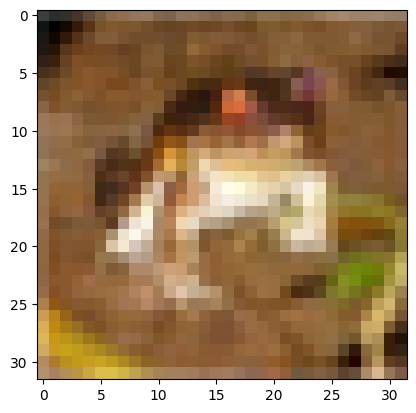

In [8]:
image = np.transpose(image, (1, 2, 0))

plt.imshow(image)
plt.show()

In [9]:
import os
import pickle
import numpy as np

import torch
from torch.utils.data import Dataset

In [10]:
## CIFAR10 Dataset Class

class CIFAR10Dataset(Dataset):
    def __init__(self, root_dir, train=True, transform=None):
        self.root_dir=root_dir
        self.train=train
        self.transform=transform
        
        self.images=[]
        self.labels=[]
        
        if train:
            batch_files = [
                "data_batch_1",
                "data_batch_2",
                "data_batch_3",
                "data_batch_4",
                "data_batch_5"
            ]
            
        else:
            batch_files=[
                "test_batch"
            ]
        
        for file_name in batch_files:
            file_path=os.path.join(root_dir, file_name)
            
            with open(file_path, "rb") as f:
                batch=pickle.load(f, encoding="bytes")
                
                self.images.append(batch[b"data"])
                self.labels.extend(batch[b"labels"])
                
                
        self.images=np.concatenate(self.images)
        self.labels=np.array(self.labels)
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        image=self.images[idx]
        label=self.labels[idx]
        
        image=image.reshape(3, 32, 32)
        image=image.astype(np.float32)/255.0
        
        image=torch.tensor(image, dtype=torch.float32)
        label=torch.tensor(label, dtype=torch.long)
        
        if self.transform:
            image=self.transform(image)
        
        return image, label

In [11]:
DATA_PATH = (
    "/Users/mac/Desktop/Machine Learning/"
    "DL/DB/CIFAR10/cifar-10-batches-py"
)

train_dataset = CIFAR10Dataset(
    root_dir=DATA_PATH,
    train=True
)

test_dataset = CIFAR10Dataset(
    root_dir=DATA_PATH,
    train=False
)

/var/folders/08/7cs_shf56lb78lkgpnm7z4bh0000gn/T/ipykernel_30220/3252902600.py:30: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  batch=pickle.load(f, encoding="bytes")


In [12]:
#check length
print(len(train_dataset))
print(len(test_dataset))

50000
10000


In [13]:
#check one sample
image, label = train_dataset[0]

print(image.shape)
print(label)

torch.Size([3, 32, 32])
tensor(6)


In [14]:
### create dataloader
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

In [15]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([128, 3, 32, 32])
torch.Size([128])
